# Dokumentasi Eksperimen Robustness (LOSO / 5-CV / Random Split)

**Notebook ini di-generate dari `scripts/build_robustness_notebook.py`** sebagai dokumentasi visual untuk evaluasi robustness top-modality models di bawah tiga protokol cross-validation subject-wise.

## Scope notebook
1. Setup & protokol robustness (LOSO, 5-Fold CV subject-wise, Random Split stratified)
2. Loading semua `*_summary.json` + `*_per_fold.json`
3. Master table per strategi (mean ± std: macro_f1, weighted_f1, accuracy)
4. Visualisasi (di-generate inline dari JSON):
   - Bar chart mean ± std macro_f1 per config × strategi
   - Distribusi per-fold (boxplot) tiap config
   - Perbandingan 3 strategi side-by-side
   - Stabilitas (std) per config
5. Tabel detail per-fold (per subjek / fold / seed)
6. Insight utama

> Eksperimen dijalankan via `scripts/run_robustness_unified.py`. Notebook ini bersifat dokumentasi & visualisasi — semua angka diambil dari hasil JSON.

---

## 1. Setup & Protokol Eksperimen

### Tiga protokol validasi
| Strategi | Unit fold | Jumlah | Deskripsi |
|---|---|---|---|
| **LOSO** | subjek | 37 | Leave-One-Subject-Out: 1 subjek test, 2 subjek val, sisanya train. Estimasi paling konservatif untuk generalisasi ke subjek baru. |
| **5-CV** | fold | 5 | 5-Fold CV subject-wise: subjek dipartisi ke 5 fold disjoint (tidak ada bocoran subjek antar train/test). |
| **Random Split** | seed | 5 | Stratified split 80/10/10 di level sampel (subjek boleh muncul di train & test), diulang 5 seed. Estimasi paling optimis (upper bound). |

### Config yang dievaluasi (top-modality per scheme)
Subset 6 config dipilih dari hasil primer unimodal/multimodal sebagai representatif terbaik per (scheme × arsitektur).

| Key | Scheme | Arch | Feature | Source | Label |
|:---:|:---:|---|---|:---:|---|
| A | 3c | fcnn | facs_28 | FA | Landmark FCNN (facs_28, FA) |
| B | 3c | intermediate | facs_28 | FA | Intermediate scratch (facs_28, FA) |
| C | 3c | late_tl | facs_28 | FA | Late Fusion TL (facs_28, FA) |
| D | 7c | cnn1d | facs_plus_bs_80 | FA | Landmark CNN1D (FB80, FA) |
| E | 7c | intermediate | facs_28 | FA | Intermediate scratch (facs_28, FA) |
| F | 7c | late_tl | raw_136 | FA | Late Fusion TL (raw_136, FA) |

### Hyperparameters (sama dengan eksperimen primer)
```
Adam, lr per-config (1e-4 / 5e-5 untuk variant TL), batch=32
epochs_max=50, patience=15, seed=42, loss=CrossEntropyLoss
model selection: best val macro_f1
```

### Dataset
`data/dataset_frontonly_conf60/` — confidence ≥ 0.6, total 6795 sampel / 37 subjek. Fold di-split di level subjek (kecuali Random Split yang di level sampel).

### Metrik
Per fold dihitung **macro_f1**, **weighted_f1**, **accuracy** pada test set fold. Ringkasan config = **mean ± std** lintas fold. macro_f1 adalah metrik utama (robust terhadap class imbalance, terutama untuk 7c).

### 1.1 Imports & paths

In [1]:
%matplotlib inline
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT = Path('..').resolve()
ROBUST = PROJECT / 'models' / 'frontonly_conf60' / 'robustness'

STRATS = [
    ('loso',        'LOSO (Leave-One-Subject-Out)', 'subjek'),
    ('cv5',         '5-Fold CV (subject-wise)',     'fold'),
    ('randomsplit', 'Random Split (stratified)',    'seed'),
]
CONFIG_ORDER = list('ABCDEF')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
print('PROJECT:', PROJECT)
print('Robustness dir:', ROBUST)
assert ROBUST.exists(), 'robustness dir tidak ditemukan'

PROJECT: /mnt/extended-home/fitra_dosen/2025_iris_fer_taufik/MultimodalEmoLearn
Robustness dir: /mnt/extended-home/fitra_dosen/2025_iris_fer_taufik/MultimodalEmoLearn/models/frontonly_conf60/robustness


## 2. Loading Semua Hasil Robustness

Loader mengiterasi `models/frontonly_conf60/robustness/{strat}/?_*_summary.json` (ringkasan mean/std) dan `*_per_fold.json` (metrik per fold).

In [2]:
def load_strategy(strat):
    """Return (summaries_df, per_fold_dict) untuk satu strategi."""
    d = ROBUST / strat
    rows, per_fold = [], {}
    for sf in sorted(d.glob('?_*_summary.json')):
        s = json.load(open(sf))
        c = s['config']
        rows.append({
            'config': s['config_key'], 'label': c['label'],
            'scheme': c['scheme'], 'arch': c['arch'],
            'feature': c['feature'], 'source': c['source'],
            'folds': f"{s['n_folds_done']}/{s['n_folds_total']}",
            'macro_f1_mean': s['test_macro_f1_mean'], 'macro_f1_std': s['test_macro_f1_std'],
            'weighted_f1_mean': s['test_weighted_f1_mean'], 'weighted_f1_std': s['test_weighted_f1_std'],
            'accuracy_mean': s['test_accuracy_mean'], 'accuracy_std': s['test_accuracy_std'],
        })
        pf = json.load(open(str(sf).replace('_summary.json', '_per_fold.json')))
        per_fold[s['config_key']] = pf
    df = pd.DataFrame(rows).set_index('config').reindex(CONFIG_ORDER)
    return df, per_fold

DATA = {strat: load_strategy(strat) for strat, _, _ in STRATS}
for strat, title, _ in STRATS:
    df, pf = DATA[strat]
    n_err = sum('error' in r for cfg in pf.values() for r in cfg)
    print(f'{title:32} | {len(df)} config | '
          f"{sum(len(v) for v in pf.values())} fold total | {n_err} error")

LOSO (Leave-One-Subject-Out)     | 6 config | 222 fold total | 0 error
5-Fold CV (subject-wise)         | 6 config | 30 fold total | 0 error
Random Split (stratified)        | 6 config | 30 fold total | 0 error


## 3. Master Table per Strategi

Setiap baris = satu config. Nilai = **mean ± std** lintas fold. Highlight = nilai tertinggi per kolom dalam scheme yang sama.

In [3]:
def fmt_pm(m, s):
    return f'{m:.4f} ± {s:.4f}'

def master_table(strat):
    df, _ = DATA[strat]
    out = pd.DataFrame(index=df.index)
    out['label'] = df['label']
    out['scheme'] = df['scheme']
    out['folds'] = df['folds']
    out['macro_f1']    = [fmt_pm(m, s) for m, s in zip(df['macro_f1_mean'], df['macro_f1_std'])]
    out['weighted_f1'] = [fmt_pm(m, s) for m, s in zip(df['weighted_f1_mean'], df['weighted_f1_std'])]
    out['accuracy']    = [fmt_pm(m, s) for m, s in zip(df['accuracy_mean'], df['accuracy_std'])]
    return out

for strat, title, _ in STRATS:
    display(Markdown(f'### {title}'))
    display(master_table(strat))
    # best macro_f1 per scheme
    df, _ = DATA[strat]
    for sch in ['3c', '7c']:
        sub = df[df['scheme'] == sch]
        best = sub['macro_f1_mean'].idxmax()
        print(f'  [{sch}] best macro_f1: config {best} '
              f"({sub.loc[best, 'label']}) = {sub.loc[best, 'macro_f1_mean']:.4f}")

### LOSO (Leave-One-Subject-Out)

,label,scheme,folds,macro_f1,weighted_f1,accuracy
config,,,,,,
A,"Landmark FCNN (facs_28, FA)",3c,37/37,0.5754 ± 0.1674,0.8665 ± 0.1196,0.8847 ± 0.1033
B,"Intermediate scratch (facs_28, FA)",3c,37/37,0.5614 ± 0.1701,0.8502 ± 0.1261,0.8581 ± 0.1284
C,"Late Fusion TL (facs_28, FA)",3c,37/37,0.5733 ± 0.1824,0.8638 ± 0.1203,0.8866 ± 0.0985
D,"Landmark CNN1D (FB80, FA)",7c,37/37,0.3438 ± 0.2472,0.7745 ± 0.2174,0.8373 ± 0.1695
E,"Intermediate scratch (facs_28, FA)",7c,37/37,0.4780 ± 0.2049,0.8509 ± 0.1234,0.8611 ± 0.1134
F,"Late Fusion TL (raw_136, FA)",7c,37/37,0.4589 ± 0.1858,0.8577 ± 0.1106,0.8767 ± 0.0948


  [3c] best macro_f1: config A (Landmark FCNN (facs_28, FA)) = 0.5754
  [7c] best macro_f1: config E (Intermediate scratch (facs_28, FA)) = 0.4780


### 5-Fold CV (subject-wise)

,label,scheme,folds,macro_f1,weighted_f1,accuracy
config,,,,,,
A,"Landmark FCNN (facs_28, FA)",3c,5/5,0.5621 ± 0.0678,0.8557 ± 0.0463,0.8787 ± 0.0429
B,"Intermediate scratch (facs_28, FA)",3c,5/5,0.5865 ± 0.0618,0.8546 ± 0.0431,0.8626 ± 0.0439
C,"Late Fusion TL (facs_28, FA)",3c,5/5,0.5259 ± 0.0738,0.8328 ± 0.0581,0.8551 ± 0.0538
D,"Landmark CNN1D (FB80, FA)",7c,5/5,0.1392 ± 0.0121,0.7688 ± 0.0559,0.8410 ± 0.0398
E,"Intermediate scratch (facs_28, FA)",7c,5/5,0.2747 ± 0.0324,0.8515 ± 0.0461,0.8655 ± 0.0433
F,"Late Fusion TL (raw_136, FA)",7c,5/5,0.2891 ± 0.0358,0.8575 ± 0.0402,0.8694 ± 0.0372


  [3c] best macro_f1: config B (Intermediate scratch (facs_28, FA)) = 0.5865
  [7c] best macro_f1: config F (Late Fusion TL (raw_136, FA)) = 0.2891


### Random Split (stratified)

,label,scheme,folds,macro_f1,weighted_f1,accuracy
config,,,,,,
A,"Landmark FCNN (facs_28, FA)",3c,5/5,0.7089 ± 0.0235,0.8950 ± 0.0081,0.9061 ± 0.0062
B,"Intermediate scratch (facs_28, FA)",3c,5/5,0.7771 ± 0.0176,0.9154 ± 0.0055,0.9169 ± 0.0052
C,"Late Fusion TL (facs_28, FA)",3c,5/5,0.7374 ± 0.0231,0.9036 ± 0.0081,0.9125 ± 0.0073
D,"Landmark CNN1D (FB80, FA)",7c,5/5,0.1297 ± 0.0000,0.7542 ± 0.0000,0.8309 ± 0.0000
E,"Intermediate scratch (facs_28, FA)",7c,5/5,0.4292 ± 0.0255,0.9038 ± 0.0037,0.9087 ± 0.0048
F,"Late Fusion TL (raw_136, FA)",7c,5/5,0.4005 ± 0.0627,0.8859 ± 0.0118,0.8953 ± 0.0105


  [3c] best macro_f1: config B (Intermediate scratch (facs_28, FA)) = 0.7771
  [7c] best macro_f1: config E (Intermediate scratch (facs_28, FA)) = 0.4292


## 4. Visualisasi

### 4.1 macro_f1 mean ± std per config × strategi

Grouped bar dengan error bar = std lintas fold. Memperlihatkan urutan optimis→konservatif: Random Split (subject leakage) > LOSO/5-CV (subject-disjoint).

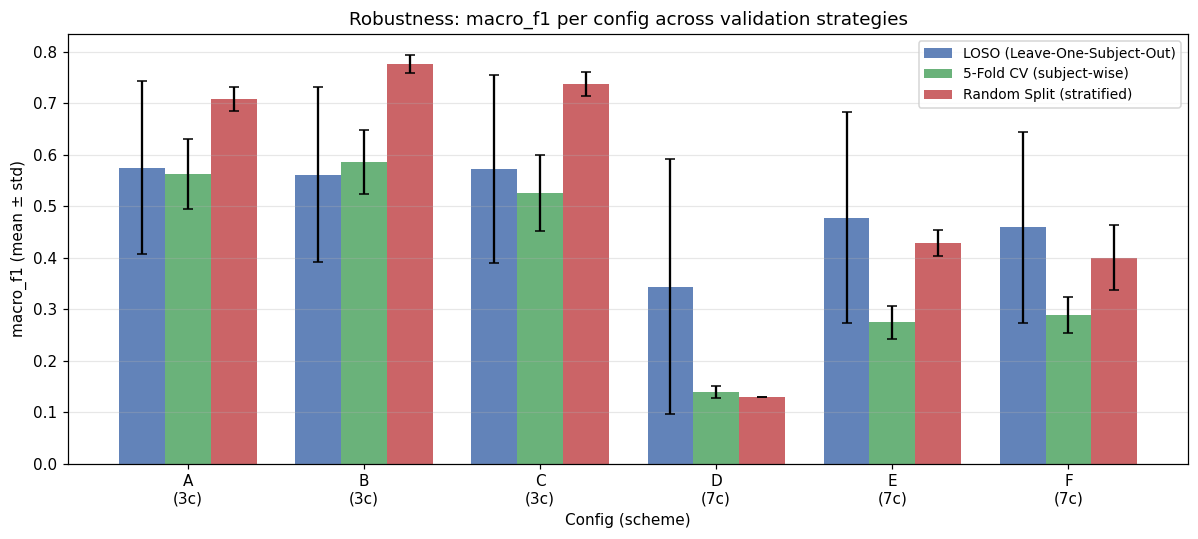

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(CONFIG_ORDER))
w = 0.26
colors = {'loso': '#4C72B0', 'cv5': '#55A868', 'randomsplit': '#C44E52'}
for i, (strat, title, _) in enumerate(STRATS):
    df, _ = DATA[strat]
    means = df['macro_f1_mean'].values
    stds = df['macro_f1_std'].values
    ax.bar(x + (i - 1) * w, means, w, yerr=stds, capsize=3,
           label=title, color=colors[strat], alpha=0.88)
labels = [f"{c}\n({DATA['loso'][0].loc[c, 'scheme']})" for c in CONFIG_ORDER]
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('macro_f1 (mean ± std)')
ax.set_xlabel('Config (scheme)')
ax.set_title('Robustness: macro_f1 per config across validation strategies')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

### 4.2 Distribusi per-fold (boxplot) — LOSO

LOSO punya 37 fold sehingga distribusinya informatif. Box lebar = sensitif terhadap identitas subjek (generalisasi tidak merata).

/tmp/claude-1013/ipykernel_2178630/181757549.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([dist[c] for c in CONFIG_ORDER], labels=CONFIG_ORDER, showmeans=True)


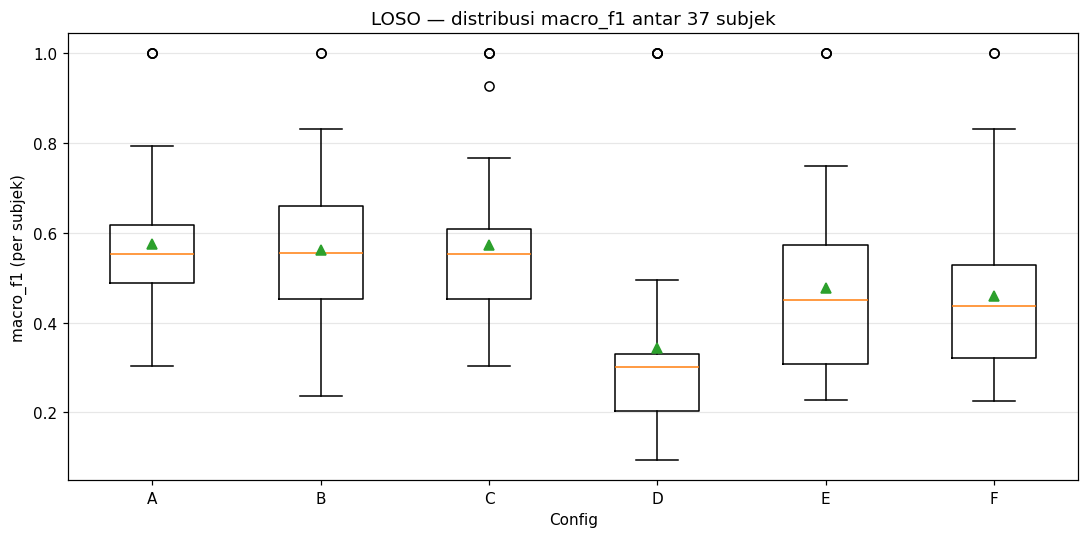

In [5]:
def per_fold_metric(strat, metric='macro_f1'):
    _, pf = DATA[strat]
    key = {'macro_f1': 'macro_f1', 'weighted_f1': 'weighted_f1', 'accuracy': 'acc'}[metric]
    return {c: [r[key] for r in pf[c] if 'error' not in r] for c in CONFIG_ORDER}

fig, ax = plt.subplots(figsize=(10, 5))
dist = per_fold_metric('loso', 'macro_f1')
ax.boxplot([dist[c] for c in CONFIG_ORDER], labels=CONFIG_ORDER, showmeans=True)
ax.set_ylabel('macro_f1 (per subjek)')
ax.set_xlabel('Config')
ax.set_title('LOSO — distribusi macro_f1 antar 37 subjek')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

### 4.3 Perbandingan 3 strategi per scheme

Rata-rata macro_f1 antar config dalam tiap scheme, dibandingkan lintas strategi. Memvisualkan gap optimis (RandomSplit) vs konservatif (LOSO).

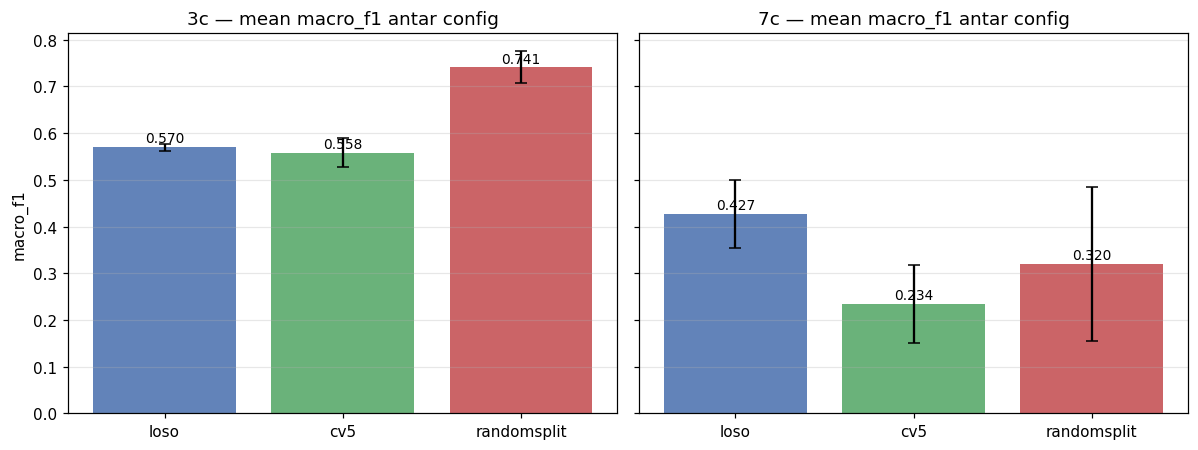

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, sch in zip(axes, ['3c', '7c']):
    vals, errs, names = [], [], []
    for strat, title, _ in STRATS:
        df, _ = DATA[strat]
        sub = df[df['scheme'] == sch]
        vals.append(sub['macro_f1_mean'].mean())
        errs.append(sub['macro_f1_mean'].std())
        names.append(strat)
    bars = ax.bar(names, vals, yerr=errs, capsize=4,
                  color=[colors[n] for n in names], alpha=0.88)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.3f}',
                ha='center', fontsize=9)
    ax.set_title(f'{sch} — mean macro_f1 antar config')
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('macro_f1')
plt.tight_layout(); plt.show()

### 4.4 Stabilitas — std macro_f1 per config

Std rendah = model stabil lintas fold (robust). LOSO biasanya paling tinggi std-nya karena variasi subjek; RandomSplit paling rendah.

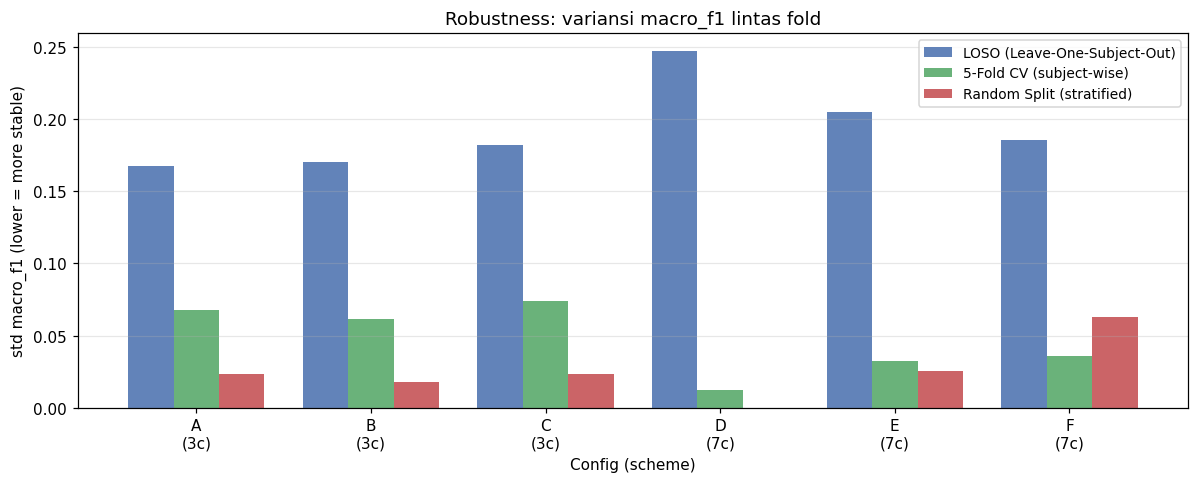

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for i, (strat, title, _) in enumerate(STRATS):
    df, _ = DATA[strat]
    ax.bar(x + (i - 1) * w, df['macro_f1_std'].values, w,
           label=title, color=colors[strat], alpha=0.88)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('std macro_f1 (lower = more stable)')
ax.set_xlabel('Config (scheme)')
ax.set_title('Robustness: variansi macro_f1 lintas fold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Tabel Detail Per-Fold

Metrik per fold/seed untuk setiap config. Baris terakhir = mean ± std agregat. Berguna untuk lampiran tesis (reproducibility per subjek).

In [8]:
def detail_table(strat, cfg):
    _, pf = DATA[strat]
    unit = dict((s, u) for s, _, u in STRATS)[strat]
    rows = []
    for r in pf[cfg]:
        if 'error' in r:
            rows.append({unit: r.get('fold_label'), 'n_train': None, 'n_val': None,
                         'n_test': None, 'macro_f1': None, 'weighted_f1': None, 'accuracy': None})
            continue
        rows.append({unit: r.get('fold_label'), 'n_train': r.get('n_tr'),
                     'n_val': r.get('n_val'), 'n_test': r.get('n_te'),
                     'macro_f1': r.get('macro_f1'), 'weighted_f1': r.get('weighted_f1'),
                     'accuracy': r.get('acc')})
    df = pd.DataFrame(rows)
    s = DATA[strat][0].loc[cfg]
    mean_row = {unit: 'mean ± std', 'n_train': '', 'n_val': '', 'n_test': '',
                'macro_f1': fmt_pm(s['macro_f1_mean'], s['macro_f1_std']),
                'weighted_f1': fmt_pm(s['weighted_f1_mean'], s['weighted_f1_std']),
                'accuracy': fmt_pm(s['accuracy_mean'], s['accuracy_std'])}
    return pd.concat([df, pd.DataFrame([mean_row])], ignore_index=True)

# Contoh: tampilkan semua config untuk LOSO. Ganti 'loso' ke 'cv5'/'randomsplit' sesuai kebutuhan.
STRAT_SHOW = 'loso'
for cfg in CONFIG_ORDER:
    s = DATA[STRAT_SHOW][0].loc[cfg]
    display(Markdown(f"### {cfg} — {s['label']} ({s['scheme']})"))
    display(detail_table(STRAT_SHOW, cfg))

### A — Landmark FCNN (facs_28, FA) (3c)

,subjek,n_train,n_val,n_test,macro_f1,weighted_f1,accuracy
0,100,6347,227,221,0.475884,0.915603,0.923077
1,101,6382,383,30,1.0,1.0,1.0
2,102,6335,321,139,0.596838,0.781485,0.769784
3,103,6265,349,181,0.488889,0.851934,0.872928
4,104,6152,378,265,0.579123,0.895131,0.90566
5,106,6285,408,102,0.590269,0.696096,0.72549
6,107,6181,314,300,0.603102,0.876621,0.896667
7,108,6162,340,293,0.536424,0.681091,0.740614
8,109,6063,449,283,0.794423,0.938163,0.939929
9,110,6144,532,119,0.346702,0.735029,0.655462


### B — Intermediate scratch (facs_28, FA) (3c)

,subjek,n_train,n_val,n_test,macro_f1,weighted_f1,accuracy
0,100,6347,227,221,0.384051,0.877062,0.909502
1,101,6382,383,30,0.447799,0.90717,0.866667
2,102,6335,321,139,0.454007,0.612125,0.597122
3,103,6265,349,181,0.415107,0.81236,0.790055
4,104,6152,378,265,0.600663,0.911441,0.916981
5,106,6285,408,102,0.575272,0.674608,0.705882
6,107,6181,314,300,0.586327,0.855462,0.873333
7,108,6162,340,293,0.549574,0.658317,0.723549
8,109,6063,449,283,0.784971,0.931143,0.929329
9,110,6144,532,119,0.236752,0.542254,0.420168


### C — Late Fusion TL (facs_28, FA) (3c)

...

,subjek,n_train,n_val,n_test,macro_f1,weighted_f1,accuracy
0,100,6347,227,221,0.316706,0.859836,0.904977
1,101,6382,383,30,0.482759,0.901149,0.933333
2,102,6335,321,139,0.134478,0.545651,0.676259
3,103,6265,349,181,0.234604,0.829539,0.883978
4,104,6152,378,265,0.219873,0.690319,0.784906
5,106,6285,408,102,0.148276,0.250034,0.421569
6,107,6181,314,300,0.133333,0.533333,0.666667
7,108,6162,340,293,0.20284,0.553829,0.682594
8,109,6063,449,283,0.314019,0.838863,0.890459
9,110,6144,532,119,0.320233,0.888041,0.92437


### E — Intermediate scratch (facs_28, FA) (7c)

,subjek,n_train,n_val,n_test,macro_f1,weighted_f1,accuracy
0,100,6347,227,221,0.592629,0.946504,0.954751
1,101,6382,383,30,0.61039,0.824242,0.766667
2,102,6335,321,139,0.248852,0.734824,0.726619
3,103,6265,349,181,0.265919,0.834613,0.823204
4,104,6152,378,265,0.468309,0.908897,0.928302
5,106,6285,408,102,0.425917,0.682674,0.72549
6,107,6181,314,300,0.304034,0.861573,0.89
7,108,6162,340,293,0.395962,0.595711,0.706485
8,109,6063,449,283,0.748474,0.932386,0.943463
9,110,6144,532,119,0.34892,0.741178,0.663866


### F — Late Fusion TL (raw_136, FA) (7c)

,subjek,n_train,n_val,n_test,macro_f1,weighted_f1,accuracy
0,100,6347,227,221,0.394602,0.857627,0.864253
1,101,6382,383,30,0.30303,0.848485,0.833333
2,102,6335,321,139,0.279558,0.761633,0.748201
3,103,6265,349,181,0.287839,0.850282,0.889503
4,104,6152,378,265,0.533413,0.897344,0.913208
5,106,6285,408,102,0.454729,0.703617,0.735294
6,107,6181,314,300,0.300847,0.854872,0.883333
7,108,6162,340,293,0.389969,0.655517,0.726962
8,109,6063,449,283,0.715884,0.913549,0.915194
9,110,6144,532,119,0.320233,0.888041,0.92437


> Untuk melihat detail **5-CV** atau **Random Split**, ubah `STRAT_SHOW` di cell di atas ke `'cv5'` atau `'randomsplit'` lalu re-run. Versi statis lengkap (ketiga strategi) tersedia di [`docs/robustness_metrics_tables.md`](../docs/robustness_metrics_tables.md).

## 6. Insight Utama

### Hierarki estimasi (optimis → konservatif)
- **Random Split > LOSO ≈ 5-CV** untuk macro_f1 3c. Random Split mengizinkan subjek yang sama muncul di train & test (subject leakage), sehingga over-estimasi generalisasi. LOSO/5-CV subject-disjoint memberi estimasi realistik untuk subjek baru.
- Gap antara Random Split dan LOSO ≈ besarnya **overfitting ke identitas subjek**.

### 3c vs 7c
- macro_f1 3c jauh lebih tinggi dari 7c di semua strategi — konsisten dengan eksperimen primer; kelas minoritas di 7c sulit dipisah dan menyeret macro_f1 ke bawah.
- weighted_f1 & accuracy 7c tetap tinggi (~0.85) → model akurat di kelas mayoritas tetapi lemah di kelas minoritas (gap macro vs weighted = sinyal imbalance).

### Stabilitas
- **LOSO punya std tertinggi** (±0.17–0.25) — performa sangat bergantung pada identitas subjek test; beberapa subjek mencapai macro_f1 1.0, sebagian < 0.35.
- **Random Split paling stabil** (std kecil) karena distribusi train/test mirip tiap seed.

### Catatan kualitas (perlu dicek)
- **Config D (CNN1D 7c) di Random Split**: std ≈ 0 di ketiga metrik → kelima seed menghasilkan output identik. Indikasi kemungkinan model collapse / prediksi kelas mayoritas saja. Layak diverifikasi terpisah sebelum dipakai sebagai klaim di tesis.

### Implikasi untuk tesis
- Laporkan **LOSO sebagai metrik generalisasi utama** (paling konservatif & relevan untuk deployment ke subjek baru), dengan Random Split sebagai upper bound dan 5-CV sebagai estimasi tengah.
- Sertakan **mean ± std** (bukan hanya mean) untuk menunjukkan variansi antar subjek.

---

*Auto-generated oleh `scripts/build_robustness_notebook.py`. Regenerate setelah sweep robustness baru selesai.*